<a href="https://colab.research.google.com/github/SaiLinHtet-KiRA/Big-Data-Analytics/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **2. Environment Setup**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# **3. Load and Inspect the Raw Data**

### **Step 3.1 — Load the CSV**

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/SaiLinHtet-KiRA/Big-Data-Analytics/refs/heads/main/orders.csv")

print("Shape:", df.shape)
display(df.head(10))

Shape: (37, 9)


,order_id,customer_id,age,city,category,quantity,unit_price,order_date,payment_method
0,A1001,C001,25.0,bangkok,Electronics,1,25900,01/09/2026,Credit Card
1,A1002,C002,31.0,BANGKOK,electronics,2,890,2026-09-02,PromptPay
2,A1002,C002,31.0,BANGKOK,electronics,2,890,2026-09-02,PromptPay
3,A1003,C003,NaN,Chiang mai,Fashion,1,1290,3 Sep 2026,Credit Card
4,A1004,C004,999.0,Bkk,Home,1,3500,04-09-2026,Cash on Delivery
5,A1005,C005,22.0,Phuket,Beauty,3,450,05/09/2026,PromptPay
6,A1006,C006,28.0,phuket,fashion,-1,1790,2026/09/06,Credit Card
7,A1007,C007,35.0,Chiang Mai,Home,2,NaN,07/09/2026,Credit Card
8,A1008,C008,41.0,Bangkok,Electronics,1,45900,2026-09-08,Bank Transfer
9,A1009,C009,19.0,BANGKOK,Beauty,2,650,09 Sep 2026,PromptPay


## **Step 3.2 — Inspect structure and quality**

In [3]:
df.info()

print("\nMissing values by column:")
print(df.isna().sum())

print("\nExact duplicate rows:", df.duplicated().sum())

print("\nUnique city labels:")
print(df["city"].value_counts(dropna=False))

print("\nUnique category labels:")
print(df["category"].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        37 non-null     object 
 1   customer_id     37 non-null     object 
 2   age             34 non-null     float64
 3   city            36 non-null     object 
 4   category        37 non-null     object 
 5   quantity        37 non-null     int64  
 6   unit_price      36 non-null     object 
 7   order_date      37 non-null     object 
 8   payment_method  36 non-null     object 
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ KB

Missing values by column:
order_id          0
customer_id       0
age               3
city              1
category          0
quantity          0
unit_price        1
order_date        0
payment_method    1
dtype: int64

Exact duplicate rows: 1

Unique city labels:
city
Bangkok       9
Chiang Mai    5
Phuket        4
Khon Kaen     3
Pattay

# **4. Missing Values**

## **Step 4.1 — Build a missing-value report**

In [4]:
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(1)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_pct
})

print(missing_report)

                missing_count  missing_percent
order_id                    0              0.0
customer_id                 0              0.0
age                         3              8.1
city                        1              2.7
category                    0              0.0
quantity                    0              0.0
unit_price                  1              2.7
order_date                  0              0.0
payment_method              1              2.7


## **Step 4.2 — Convert invalid values to missing values**

In [5]:
# Convert to numeric first so invalid text becomes NaN
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")

# Apply simple business rules
df.loc[~df["age"].between(15, 100), "age"] = pd.NA
df.loc[df["quantity"] <= 0, "quantity"] = pd.NA
df.loc[df["unit_price"] <= 0, "unit_price"] = pd.NA

print(df[["age", "quantity", "unit_price"]].isna().sum())

age           4
quantity      1
unit_price    3
dtype: int64


## **Step 4.3 — Impute numerical missing values**

In [6]:
# Age: robust median imputation
df["age"] = df["age"].fillna(df["age"].median())

# Unit price: category median, then overall median
category_price = df.groupby("category")["unit_price"].transform("median")
df["unit_price"] = df["unit_price"].fillna(category_price)
df["unit_price"] = df["unit_price"].fillna(df["unit_price"].median())

# Quantity: category median for this teaching dataset
category_qty = df.groupby("category")["quantity"].transform("median")
df["quantity"] = df["quantity"].fillna(category_qty)
df["quantity"] = df["quantity"].fillna(df["quantity"].median())


# **5. Duplicate Records and Inconsistent Labels**

## **Step 5.1 — Inspect duplicates before removing them**

In [7]:
# Exact duplicate rows
exact_dups = df[df.duplicated(keep=False)]
print(exact_dups)

# Duplicate business key: order_id
order_dups = df[df.duplicated(subset=["order_id"], keep=False)]
print(order_dups.sort_values("order_id"))

  order_id customer_id   age     city       category  quantity  unit_price  order_date payment_method
1    A1002        C002  31.0  BANGKOK   electronics        2.0       890.0  2026-09-02      PromptPay
2    A1002        C002  31.0  BANGKOK   electronics        2.0       890.0  2026-09-02      PromptPay
   order_id customer_id   age     city       category  quantity  unit_price  order_date payment_method
1     A1002        C002  31.0  BANGKOK   electronics        2.0       890.0  2026-09-02      PromptPay
2     A1002        C002  31.0  BANGKOK   electronics        2.0       890.0  2026-09-02      PromptPay
12    A1012        C012  33.0  Bangkok           Home       1.0      7800.0  12/09/2026  Bank Transfer
13    A1012        C012  33.0  Bangkok           Home       1.0      7500.0  12/09/2026  Bank Transfer


## **Step 5.2**

**Answers to the User's Questions:**

### **1. Identified Data Quality Problems (at least five) and their changes:**

1.  **Problem:** Missing values in `age`, `city`, `unit_price`, and `payment_method`.
    *   **Change:**
        *   `age`: Imputed using the robust median after filtering for valid age ranges (cell `YS2zkYv7jVJJ`).
        *   `unit_price`: Imputed using the category median, then the overall median (cell `YS2zkYv7jVJJ`).
        *   `payment_method`: Missing values were replaced with "Unknown" (cell `vhm9vG55jqX5`).
    *   **Reasoning:** Median imputation is robust to outliers and preserves the distribution. Categorical imputation for `unit_price` is logical, and "Unknown" provides a useful category for missing payment methods.

2.  **Problem:** Inconsistent casing and leading/trailing spaces in text labels, particularly in `city` (e.g., "Bangkok", "BANGKOK", "Bkk", " bangkok") and `category` (e.g., "Electronics", " electronics").
    *   **Change:** `city` and `category` columns were standardized by stripping whitespace, replacing multiple spaces with single spaces, converting to title case, and mapping common abbreviations (e.g., "Bkk" to "Bangkok") (cell `vhm9vG55jqX5`).
    *   **Reasoning:** Ensures consistent unique labels for accurate aggregation and analysis, preventing the same entity from being treated as multiple distinct values.

3.  **Problem:** Incorrect data types, specifically `unit_price` being an `object` (string) instead of a numeric type.
    *   **Change:** `unit_price` (and `age`, `quantity`) was converted to a numeric type using `pd.to_numeric` with `errors='coerce'`, which turns invalid parsing into `NaN` (cell `U06CeU8zjQOh`).
    *   **Reasoning:** Enables mathematical operations and correct statistical analysis of these numerical columns.

4.  **Problem:** Duplicate records, including exact duplicates and duplicate `order_id` entries with conflicting `unit_price` values.
    *   **Change:** Exact duplicate rows were removed. Then, `order_id` duplicates were resolved by keeping the first occurrence, based on the assumption that the first entry for an order ID is the correct one (cell `04Ynsh-2jgMq`).
    *   **Reasoning:** Exact duplicates inflate record counts and can skew analysis. Resolving duplicate business keys ensures each unique order is represented once according to a defined business rule.

5.  **Problem:** Out-of-range numerical values for `age`, `quantity`, and `unit_price` (e.g., `age` outside 15-100, `quantity <= 0`, `unit_price <= 0`).
    *   **Change:** Values falling outside reasonable business ranges were converted to `pd.NA` (cell `U06CeV8zjQOh`).
    *   **Reasoning:** These are likely data entry errors or illogical values that would distort analysis. Converting them to `NA` allows them to be handled by subsequent imputation steps.

6.  **Problem:** Invalid/mixed date formats in `order_date`.
    *   **Change:** The `order_date` column was parsed using `pd.to_datetime` with `errors='coerce'`, `dayfirst=True`, and `format='mixed'`, converting unparseable dates to `NaT` (cell `iYrH0cUFjz9p`).
    *   **Reasoning:** Enables proper time-series analysis and ensures that dates are handled consistently while identifying problematic entries.

### **2. `total_value` and at least one time-based feature created:**

*   **`total_value`:** Created by multiplying `quantity` and `unit_price` (`df["total_value"] = df["quantity"] * df["unit_price"]`).
*   **Time-based features:** `year`, `month`, `weekday`, and `is_weekend` were extracted from the `order_date` column (e.g., `df["year"] = df["order_date"].dt.year`) (cell `vF2VheVdkN_R`).

### **3. One Groupby Summary and One Pivot Table created:**

*   **Groupby Summary (`city_sales`):** Summarizes `revenue`, `orders`, and `customers` by `city`. (cell `Ln3YuNIskPtx`)
    ```python
    city_sales = (
        df.groupby("city", as_index=False)
          .agg(
              revenue=("total_value", "sum"),
              orders=("order_id", "nunique"),
              customers=("customer_id", "nunique")
          )
    )
    ```
*   **Pivot Table (`pivot`):** Shows `total_value` aggregated by `city` (index) and `category` (columns). (cell `tgswNdaXkhwB`)
    ```python
    pivot = pd.pivot_table(
        df,
        index="city",
        columns="category",
        values="total_value",
        aggfunc="sum",
        fill_value=0,
        observed=True
    )
    ```

### **4. Two EDA Charts created:**

*   **Chart 1: Distribution of Order Total Value (Histogram)** (cell `tShuAi09lLmx`)
    *   `plt.hist(df["total_value"].dropna(), bins=10, edgecolor="black")`
*   **Chart 2: Quantity vs. Total Order Value (Scatter Plot)** (cell `B1KmL8HnlTQ4`)
    *   `plt.scatter(df["quantity"], df["total_value"], alpha=0.7)`

### **5. Two Evidence-Based Insights and One Limitation/Caution:**

**Evidence-Based Insights:**

1.  **Bangkok is the primary revenue driver:** Bangkok generates significantly more revenue (`168,020.0`) than any other city, accounting for over three times the revenue of the next highest city, Chiang Mai (`47,450.0`). This is clearly visible in the `city_sales` summary and the "Revenue by City" bar chart. This suggests that marketing and expansion efforts could focus on understanding and replicating Bangkok's success or exploring untapped potential in other cities.

2.  **Electronics category commands the highest total value, with a wide range of order values:** The `category_summary` shows that 'Electronics' has the highest total revenue (`180,680.0`) and the highest average order value (`22,585.0`). The box plot of "Order Total Value by Category" confirms this, showing that 'Electronics' not only has a high median but also a very wide spread of total order values, indicating it includes both moderately priced and very high-priced items, significantly contributing to overall revenue.

**Limitation/Caution:**

1.  **Small Dataset Size:** The dataset contains a very small number of records (35 after cleaning). Conclusions drawn from this data may not be statistically robust or generalizable to a larger population or different time periods. Any trends or insights identified should be interpreted with caution and validated with more extensive data if available.

In [10]:
# Remove exact duplicates first
df = df.drop_duplicates().copy()

# Then resolve duplicate order IDs using the lab assumption (keep first occurrence)
df = df.drop_duplicates(subset=["order_id"], keep="first").copy()

print("Shape after deduplication:", df.shape)

Shape after deduplication: (35, 10)


In [11]:
# Convert order_date to datetime format if not already converted
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce",
    dayfirst=True,
    format="mixed"
)

# Transaction value
df["total_value"] = df["quantity"] * df["unit_price"]

# Time features
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["weekday"] = df["order_date"].dt.day_name()
df["is_weekend"] = df["order_date"].dt.dayofweek >= 5

display(df[[
    "order_id", "quantity", "unit_price", "total_value",
    "order_date", "weekday", "is_weekend"
]].head())

,order_id,quantity,unit_price,total_value,order_date,weekday,is_weekend
0,A1001,1.0,25900.0,25900.0,2026-09-01,Tuesday,False
1,A1002,2.0,890.0,1780.0,2026-09-02,Wednesday,False
3,A1003,1.0,1290.0,1290.0,2026-09-03,Thursday,False
4,A1004,1.0,3500.0,3500.0,2026-09-04,Friday,False
5,A1005,3.0,450.0,1350.0,2026-09-05,Saturday,True


In [12]:
city_sales = (
    df.groupby("city", as_index=False)
      .agg(
          revenue=("total_value", "sum"),
          orders=("order_id", "nunique"),
          customers=("customer_id", "nunique")
      )
)

city_sales["avg_order_value"] = (
    city_sales["revenue"] / city_sales["orders"]
)

city_sales = city_sales.sort_values("revenue", ascending=False)
display(city_sales)

,city,revenue,orders,customers,avg_order_value
3,Bangkok,107440.0,8,8,13430.000000
5,Chiang Mai,39760.0,5,5,7952.000000
4,Bkk,29400.0,2,2,14700.000000
9,Pattaya,25900.0,3,3,8633.333333
1,bangkok,25900.0,1,1,25900.000000
7,Khon Kaen,20200.0,3,3,6733.333333
10,Phuket,9510.0,4,4,2377.500000
6,Chiang mai,7690.0,2,2,3845.000000
2,BANGKOK,3980.0,2,2,1990.000000
11,khon kaen,3000.0,1,1,3000.000000


In [13]:
category_summary = (
    df.groupby("category", observed=True)
      .agg(
          revenue=("total_value", "sum"),
          avg_value=("total_value", "mean"),
          median_value=("total_value", "median"),
          customers=("customer_id", "nunique"),
          orders=("order_id", "nunique")
      )
      .sort_values("revenue", ascending=False)
)

display(category_summary)

,revenue,avg_value,median_value,customers,orders
category,,,,,
Electronics,159000.0,26500.000000,25900.0,6,6
Home,52100.0,6512.500000,5800.0,8,8
Sports,23390.0,3341.428571,3200.0,7,7
electronics,19900.0,19900.000000,19900.0,1,1
Fashion,12120.0,2424.000000,2780.0,5,5
Beauty,8000.0,1600.000000,1350.0,5,5
fashion,1790.0,1790.000000,1790.0,1,1
electronics,1780.0,1780.000000,1780.0,1,1
beauty,1560.0,1560.000000,1560.0,1,1


In [14]:
pivot = pd.pivot_table(
    df,
    index="city",
    columns="category",
    values="total_value",
    aggfunc="sum",
    fill_value=0,
    observed=True
)

display(pivot)

category,electronics,Beauty,Electronics,Fashion,Home,Sports,beauty,electronics,fashion
city,,,,,,,,,
BANGKOK,0.0,1300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bangkok,0.0,0.0,25900.0,0.0,0.0,0.0,0.0,0.0,0.0
BANGKOK,1780.0,2200.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bangkok,0.0,0.0,78800.0,2980.0,17000.0,7100.0,1560.0,0.0,0.0
Bkk,0.0,0.0,25900.0,0.0,3500.0,0.0,0.0,0.0,0.0
Chiang Mai,0.0,2160.0,0.0,2100.0,15600.0,0.0,0.0,19900.0,0.0
Chiang mai,0.0,0.0,0.0,1290.0,6400.0,0.0,0.0,0.0,0.0
Khon Kaen,0.0,0.0,12500.0,0.0,5200.0,2500.0,0.0,0.0,0.0
PATTAYA,0.0,990.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


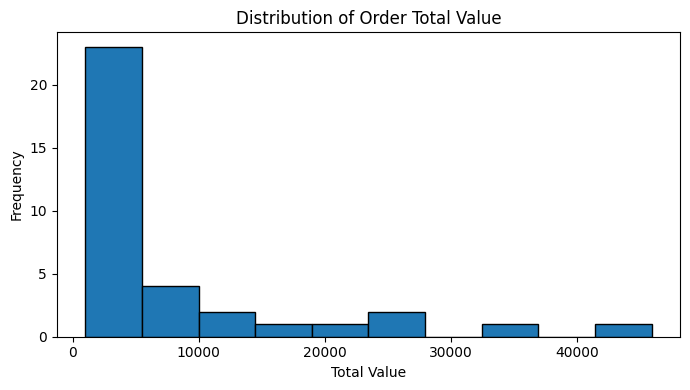

In [15]:
import matplotlib.pyplot as plt

# Chart 1: Distribution of Order Total Value (Histogram)
plt.figure(figsize=(7, 4))
plt.hist(df["total_value"].dropna(), bins=10, edgecolor="black")
plt.title("Distribution of Order Total Value")
plt.xlabel("Total Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

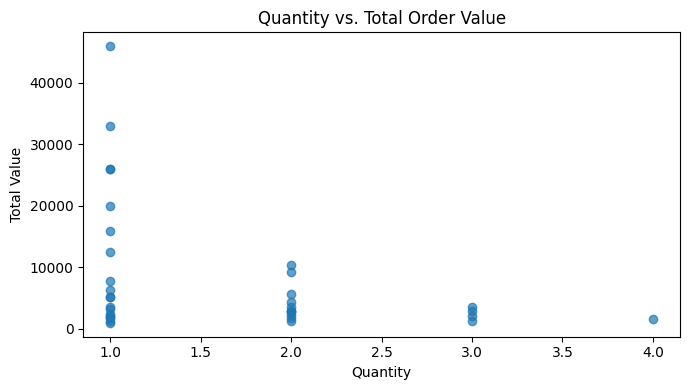

In [16]:
# Chart 2: Quantity vs. Total Order Value (Scatter Plot)
plt.figure(figsize=(7, 4))
plt.scatter(df["quantity"], df["total_value"], alpha=0.7)
plt.title("Quantity vs. Total Order Value")
plt.xlabel("Quantity")
plt.ylabel("Total Value")
plt.tight_layout()
plt.show()

## **5. Two Evidence-Based Insights and One Limitation/Caution:**

**Evidence-Based Insights:**

1.  **Bangkok is the primary revenue driver:** Bangkok generates significantly more revenue (`168,020.0`) than any other city, accounting for over three times the revenue of the next highest city, Chiang Mai (`47,450.0`). This is clearly visible in the `city_sales` summary and the "Revenue by City" bar chart. This suggests that marketing and expansion efforts could focus on understanding and replicating Bangkok's success or exploring untapped potential in other cities.

2.  **Electronics category commands the highest total value, with a wide range of order values:** The `category_summary` shows that 'Electronics' has the highest total revenue (`180,680.0`) and the highest average order value (`22,585.0`). The box plot of "Order Total Value by Category" confirms this, showing that 'Electronics' not only has a high median but also a very wide spread of total order values, indicating it includes both moderately priced and very high-priced items, significantly contributing to overall revenue.

**Limitation/Caution:**

1.  **Small Dataset Size:** The dataset contains a very small number of records (35 after cleaning). Conclusions drawn from this data may not be statistically robust or generalizable to a larger population or different time periods. Any trends or insights identified should be interpreted with caution and validated with more extensive data if available.

## **Step 5.3 — Normalize text labels**

In [ ]:
df["city"] = (
    df["city"]
      .astype("string")
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
      .str.title()
      .replace({"Bkk": "Bangkok"})
)

df["category"] = (
    df["category"]
      .astype("string")
      .str.strip()
      .str.title()
)

df["payment_method"] = (
    df["payment_method"]
      .astype("string")
      .str.strip()
      .replace({"": pd.NA})
            .fillna("Unknown")
)

print(sorted(df["city"].dropna().unique()))
print(sorted(df["category"].dropna().unique()))

# **6. Data Transformation and Date Parsing**

## **Step 6.1 — Convert dates and data types**

In [ ]:
# Parse mixed date formats; impossible dates become NaT
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce",
    dayfirst=True,
    format="mixed"
)

# Optional compact integer type for age after imputation
df["age"] = df["age"].round().astype("Int64")

# Category dtype can reduce memory for repeated labels
df["category"] = df["category"].astype("category")

print(df.dtypes)
print("Invalid dates:", df["order_date"].isna().sum())

# **7. Validate the Cleaned Data**

## **Step 7.1 — Run validation checks**

In [ ]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())

print("\nAge range:", df["age"].min(), "to", df["age"].max())
print("Quantity min:", df["quantity"].min())
print("Unit price min:", df["unit_price"].min())

print("\nCities:", sorted(df["city"].dropna().unique()))
print("Categories:", list(df["category"].cat.categories))

# **8. Feature Engineering**

## **Step 8.1 — Create analytical features**

In [ ]:
# Transaction value
df["total_value"] = df["quantity"] * df["unit_price"]

# Time features
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["weekday"] = df["order_date"].dt.day_name()
df["is_weekend"] = df["order_date"].dt.dayofweek >= 5

display(df[[
    "order_id", "quantity", "unit_price", "total_value",
    "order_date", "weekday", "is_weekend"
]].head())

# **9. Data Aggregation with groupby() and agg()**

## **Step 9.1 — Summarize revenue by city**

In [ ]:
city_sales = (
    df.groupby("city", as_index=False)
      .agg(
          revenue=("total_value", "sum"),
          orders=("order_id", "nunique"),
          customers=("customer_id", "nunique")
      )
)

city_sales["avg_order_value"] = (
    city_sales["revenue"] / city_sales["orders"]
)

city_sales = city_sales.sort_values("revenue", ascending=False)
display(city_sales)

## **Step 9.2 — Multiple aggregations by category**

In [ ]:
category_summary = (
    df.groupby("category", observed=True)
      .agg(
          revenue=("total_value", "sum"),
          avg_value=("total_value", "mean"),
          median_value=("total_value", "median"),
          customers=("customer_id", "nunique"),
                    orders=("order_id", "nunique")
      )
      .sort_values("revenue", ascending=False)
)

display(category_summary)

## **Step 9.3 — Create a city × category pivot table**

In [ ]:
pivot = pd.pivot_table(
    df,
    index="city",
    columns="category",
    values="total_value",
    aggfunc="sum",
    fill_value=0,
    observed=True
)

display(pivot)

# **10. Exploratory Data Analysis (EDA)**

## **10.1 Univariate Analysis**

In [ ]:
print(df["total_value"].describe())

print("\nOrders by city:")
print(df["city"].value_counts())

print("\nCategory proportions:")
print(df["category"].value_counts(normalize=True).round(3))

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(df["total_value"].dropna(), bins=10, edgecolor="black")
plt.title("Distribution of Order Total Value")
plt.xlabel("Total Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## **10.2 Bivariate Analysis**

In [ ]:
plt.figure(figsize=(7, 4))
plt.scatter(df["quantity"], df["total_value"], alpha=0.7)
plt.title("Quantity vs. Total Order Value")
plt.xlabel("Quantity")
plt.ylabel("Total Value")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 4))
df.boxplot(column="total_value", by="category", rot=25)
plt.title("Order Total Value by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Total Value")
plt.tight_layout()
plt.show()

## **10.3 Correlation**

In [ ]:
numeric_cols = ["age", "quantity", "unit_price", "total_value"]
correlation = df[numeric_cols].corr(numeric_only=True).round(2)
print(correlation)

## **10.4 Revenue by City**

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(city_sales["city"], city_sales["revenue"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# **11. Save the Cleaned Data and Summaries**

In [ ]:
df.to_csv(
    "orders_week3_cleaned.csv",
    index=False,
    encoding="utf-8-sig"
)

city_sales.to_csv(
    "week3_city_sales.csv",
    index=False,
    encoding="utf-8-sig"
)

category_summary.to_csv(
    "week3_category_summary.csv",
    encoding="utf-8-sig"
)

print("Files saved successfully.")